# Plot PPCs for GWTC-4.0 Default Model

In [1]:
import numpy as np 
import h5ify
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import math
import seaborn as sns
sns.set_palette('colorblind')

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', serif='Computer Modern Roman')

## Load data (calculated in `get_PPC_traces.py`)

In [2]:
# Load
PPC_traces_dict = h5ify.load('PPC_traces.h5').copy()

In [3]:
# Labels
parameter_labels = {
    'mass_1':r'$m_1~[M_\odot]$',
    'mass_ratio':r'$q$',
    'redshift':r'$z$',
    'a_1':r'$\chi_1$',
    'a_2':r'$\chi_2$',
    'cos_tilt_1':r'$\cos\theta_1$',
    'cos_tilt_2':r'$\cos\theta_2$',
}

In [4]:
# Sort the traces
PPC_traces_dict_sorted = PPC_traces_dict.copy()
for param in parameter_labels.keys(): 

    obs_traces = np.sort(PPC_traces_dict_sorted['observed'][param], axis=1)
    pred_traces = np.sort(PPC_traces_dict_sorted['predicted'][param], axis=1)
    
    PPC_traces_dict_sorted['observed'][param] = obs_traces
    PPC_traces_dict_sorted['predicted'][param] = pred_traces

## Plot PPCs: Compare predicted vs. observed CDFs

<>:39: SyntaxWarning: invalid escape sequence '\%'
<>:39: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1157/1903608051.py:39: SyntaxWarning: invalid escape sequence '\%'
  Patch(color='gray', alpha=0.3, label='90\% CI')


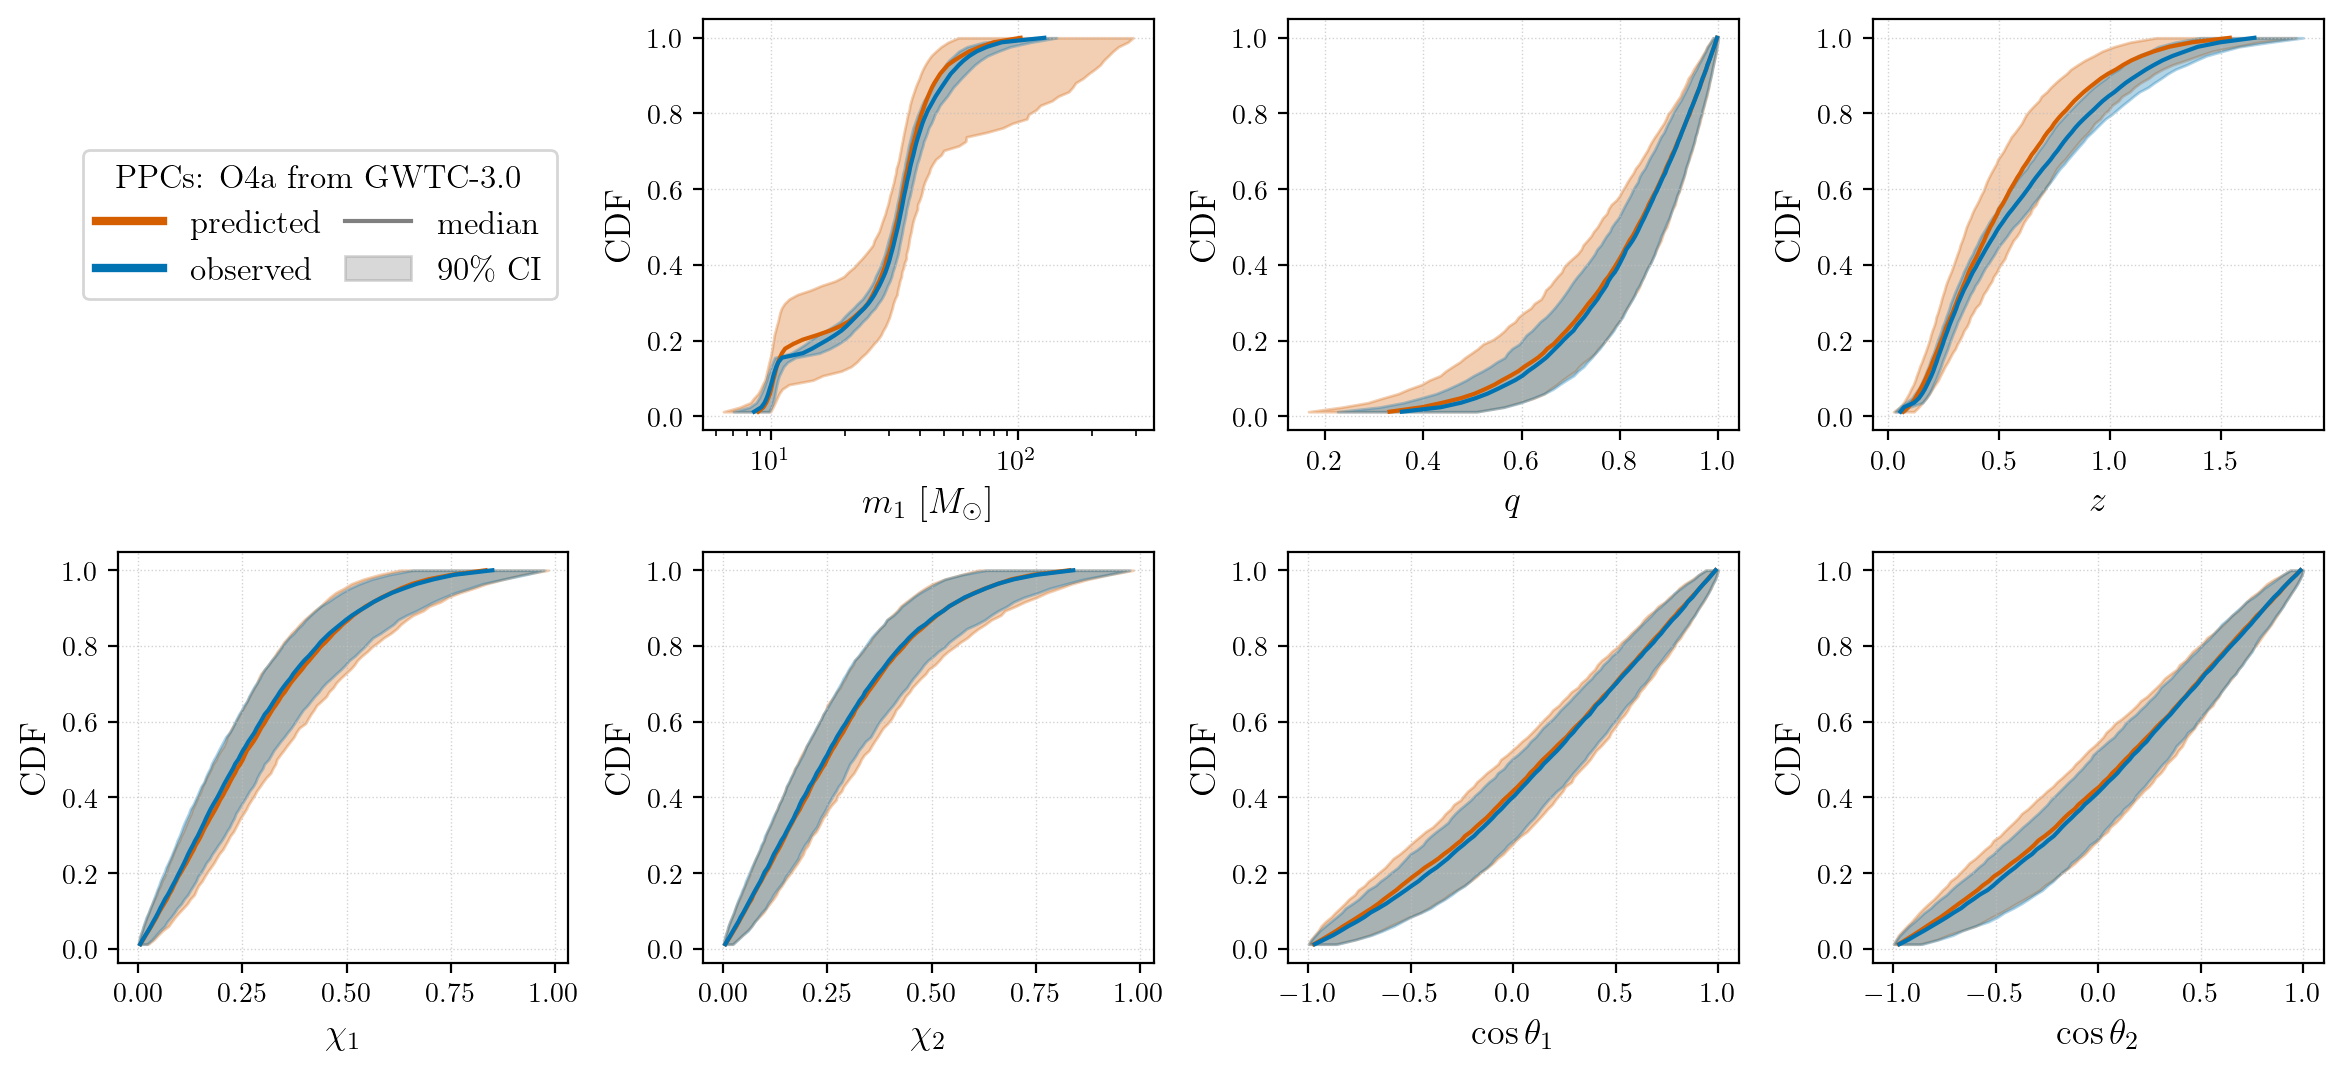

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(13/1.1,6/1.1))

nevents = 84
dx = 1.0/nevents
CDF = np.arange(dx,1+dx,dx)

for param, label, ax in zip(
    parameter_labels.keys(),   # parameter key 
    parameter_labels.values(), # parameter latex label
    axes.flatten()[1:]         # axis
): 

    obs_traces = PPC_traces_dict_sorted['observed'][param] 
    pred_traces = PPC_traces_dict_sorted['predicted'][param]

    obs_5, obs_50, obs_95 = np.quantile(obs_traces, (0.05, 0.5, 0.95), axis=0)
    pred_5, pred_50, pred_95 = np.quantile(pred_traces, (0.05, 0.5, 0.95), axis=0)
    
    ax.plot(pred_50, CDF, color='C3')
    ax.fill_betweenx(CDF, pred_5, pred_95, color='C3', alpha=0.3)

    ax.plot(obs_50, CDF, color='C0')
    ax.fill_betweenx(CDF, obs_5, obs_95, color='C0', alpha=0.3)

    ax.grid(color='silver', ls=':', lw=0.5, alpha=0.7)

    ax.set_xlabel(label, fontsize=13)
    ax.set_ylabel('CDF', fontsize=13)
    
axes[0,0].set_visible(False)
axes[0,1].set_xscale('log')

plt.tight_layout()

handles = [
    Line2D([], [], color='C3', lw=3, label='predicted'), 
    Line2D([], [], color='C0', lw=3, label='observed'), 
    Line2D([], [], color='gray', label='median'), 
    Patch(color='gray', alpha=0.3, label='90\% CI')
]
axes[0,1].legend(
    handles=handles, fontsize=12, bbox_to_anchor=[-0.85, 0.5], loc='center',
    title='PPCs: O4a from GWTC-3.0',  title_fontsize=12, ncols=2, columnspacing=0.7
)

plt.savefig('PPCs.pdf', bbox_inches='tight')
plt.show()